## **Spatial Clustering of Molecular Localizations Using MIRO**

This tutorial demonstrates how to train and apply **MIRO** to cluster spatial point clouds obtained from single-molecule localization microscopy (SMLM). Specifically, we show how to use MIRO on benchmark data introduced in [Nieves et al., *Nature Methods* (2023)](https://www.nature.com/articles/s41592-022-01750-6), which provides a standardized framework for evaluating clustering methods in SMLM.


### **1. Download the data**


To begin, download the benchmark dataset using the `sdownload` function. 

This function requires three parameters: `id`, which specifies the dataset to download (in this case, `id=6`); `local_folder`, the target directory where the data will be stored; and `blinking`, a boolean indicating whether to include fluorophore blinking effects. 

The function returns the path to the downloaded dataset, which will be used for training and evaluation.


In [ ]:
import sys
from pathlib import Path

# Ensure the library path is in sys.path
lib_path = Path.cwd().parent.resolve()

if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))

import lib

BLINKING = False

current_path = Path.cwd()
path = current_path / "csv_generats"


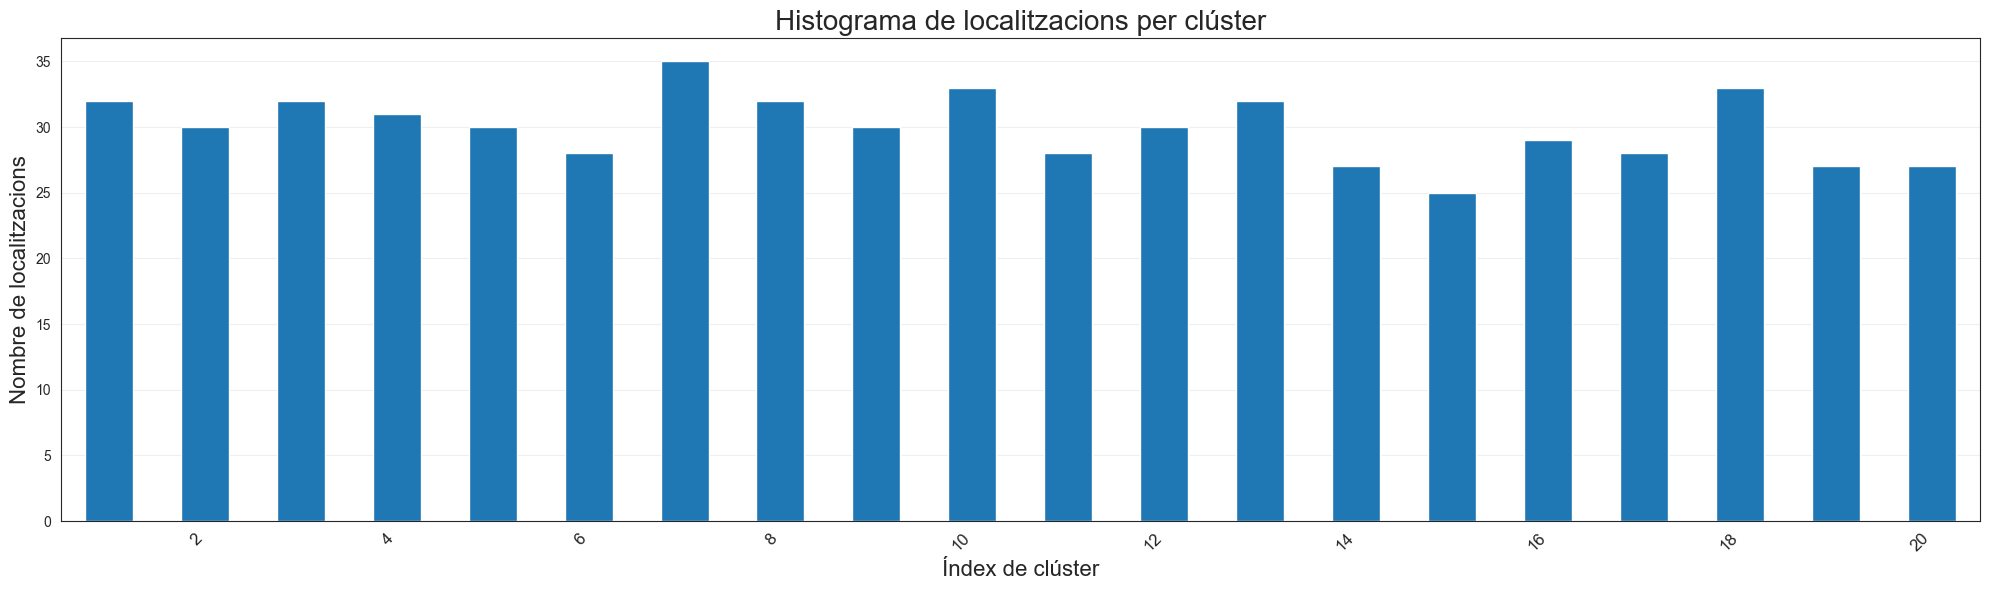

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

path = Path.cwd() / "csv_generats"
primer_csv = sorted(path.glob("*.csv"))[0]

df = pd.read_csv(primer_csv)

col_cluster = "index"

df_filtrat = df[df[col_cluster] != 0]

plt.figure(figsize=(20, 6))
df_filtrat[col_cluster].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Índex de clúster", fontsize=16)
plt.ylabel("Nombre de localitzacions", fontsize=16)
plt.title(f"Histograma de localitzacions per clúster", fontsize=20)

plt.grid(axis="y", alpha=0.3)
ticks = df_filtrat[col_cluster].value_counts().sort_index().index
plt.xticks(ticks[::2], rotation=45, ha="right", fontsize=12)

plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

plt.show()

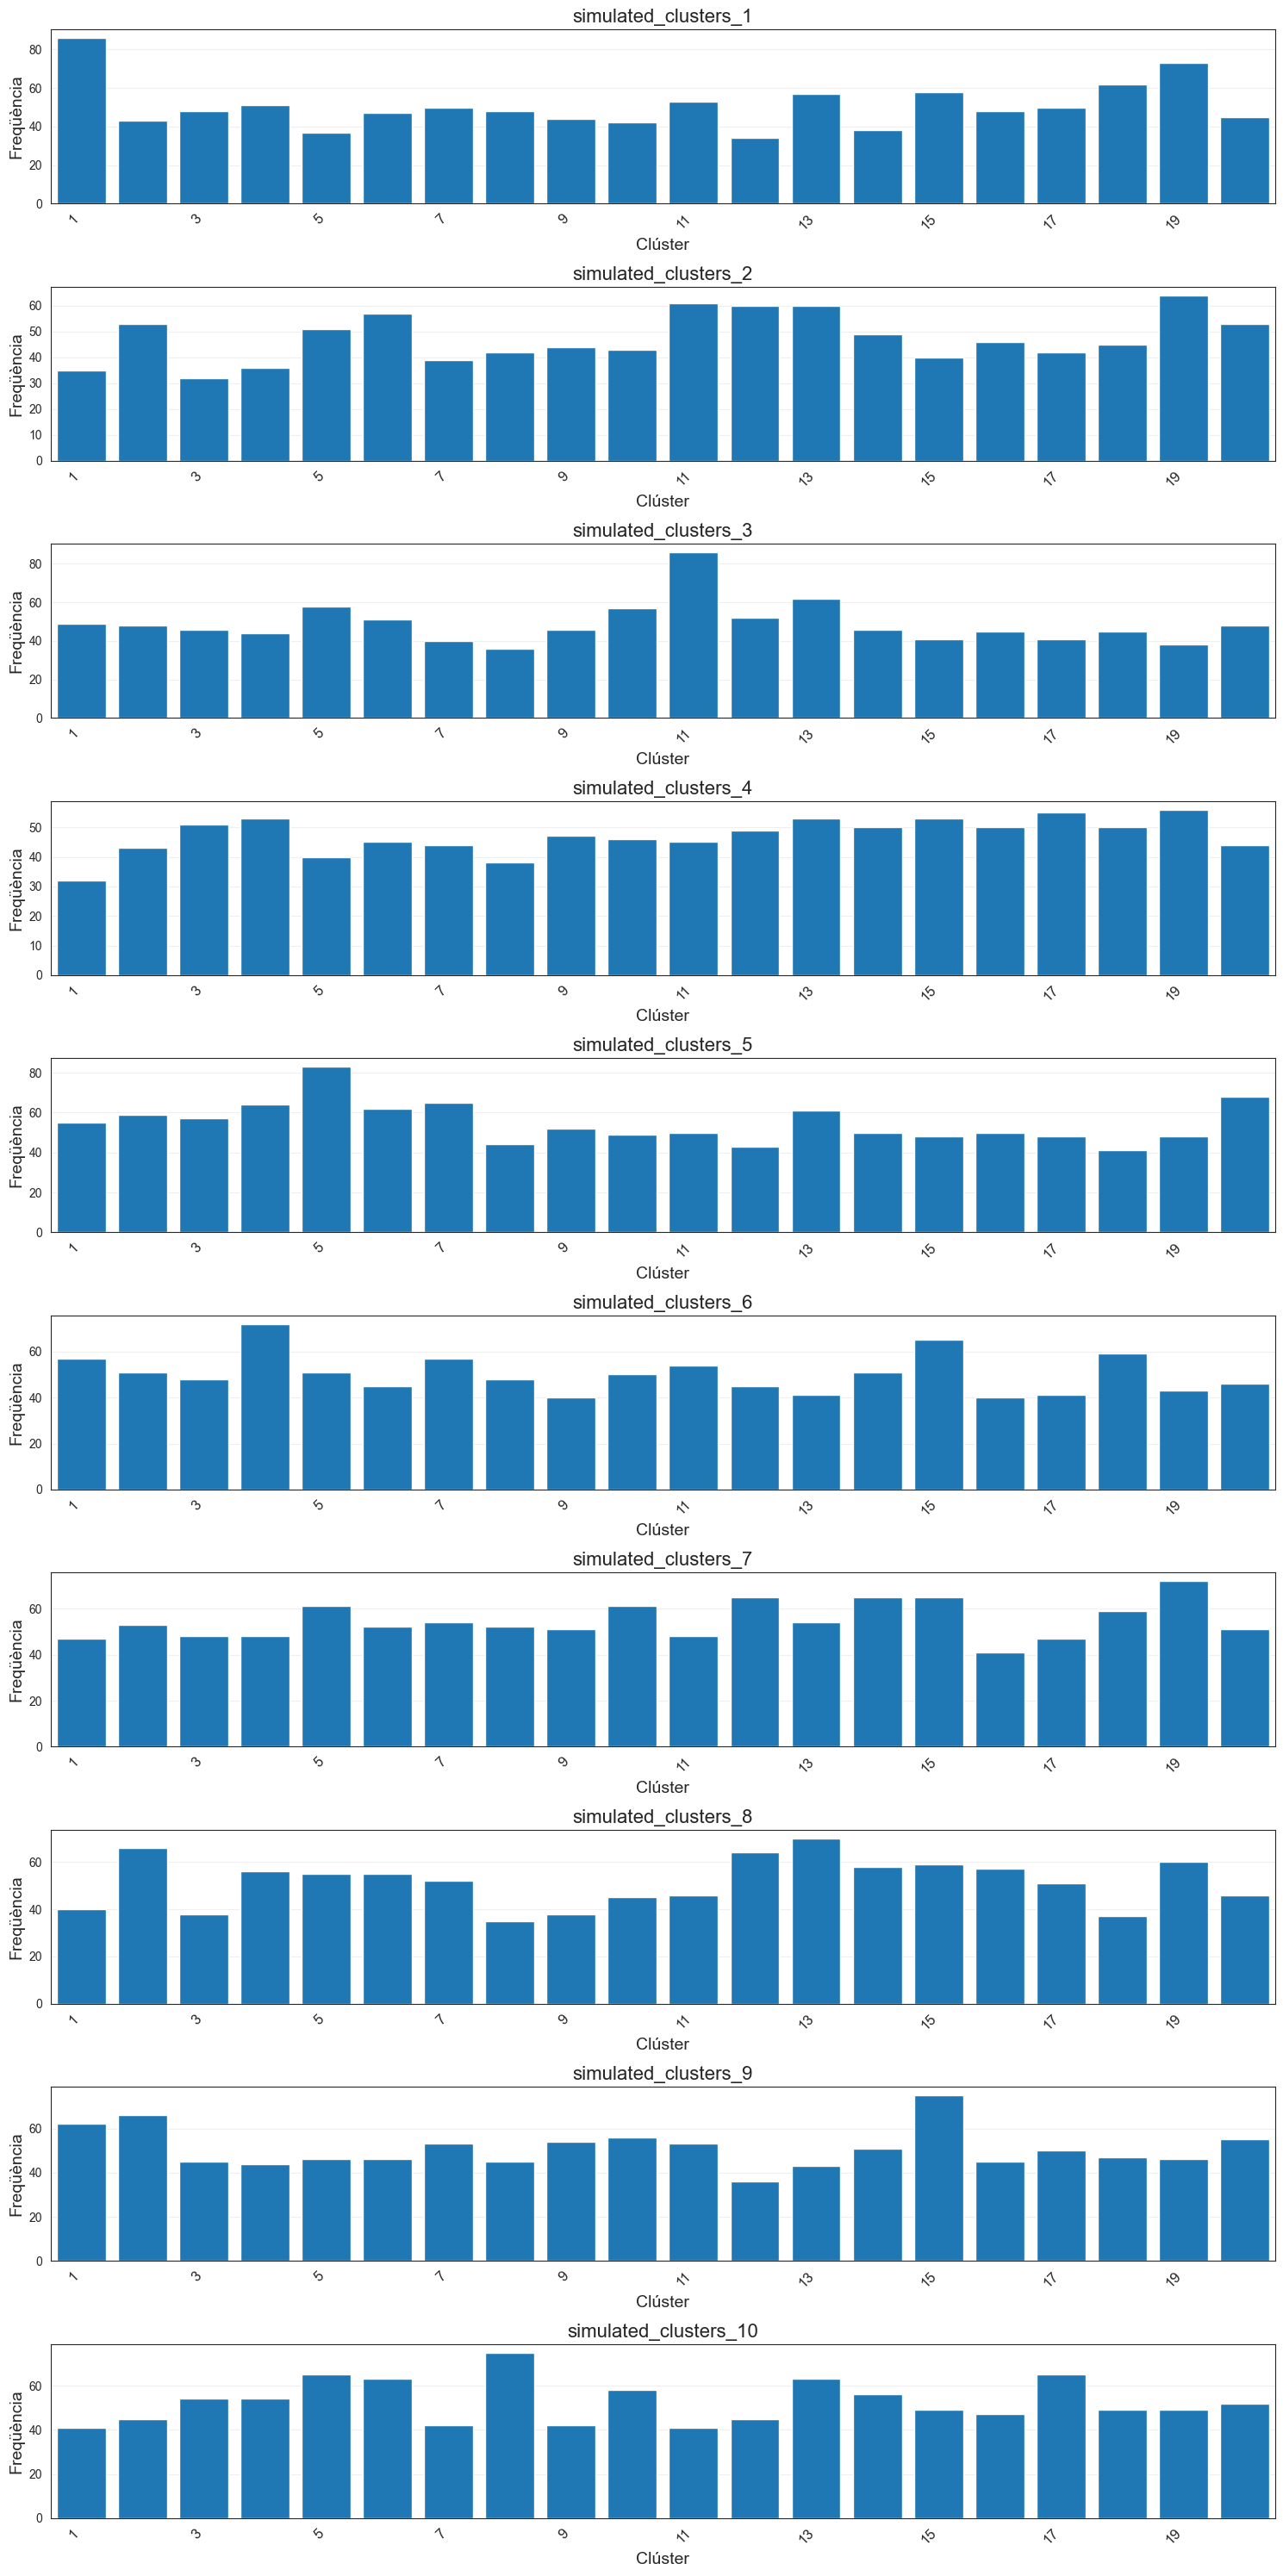

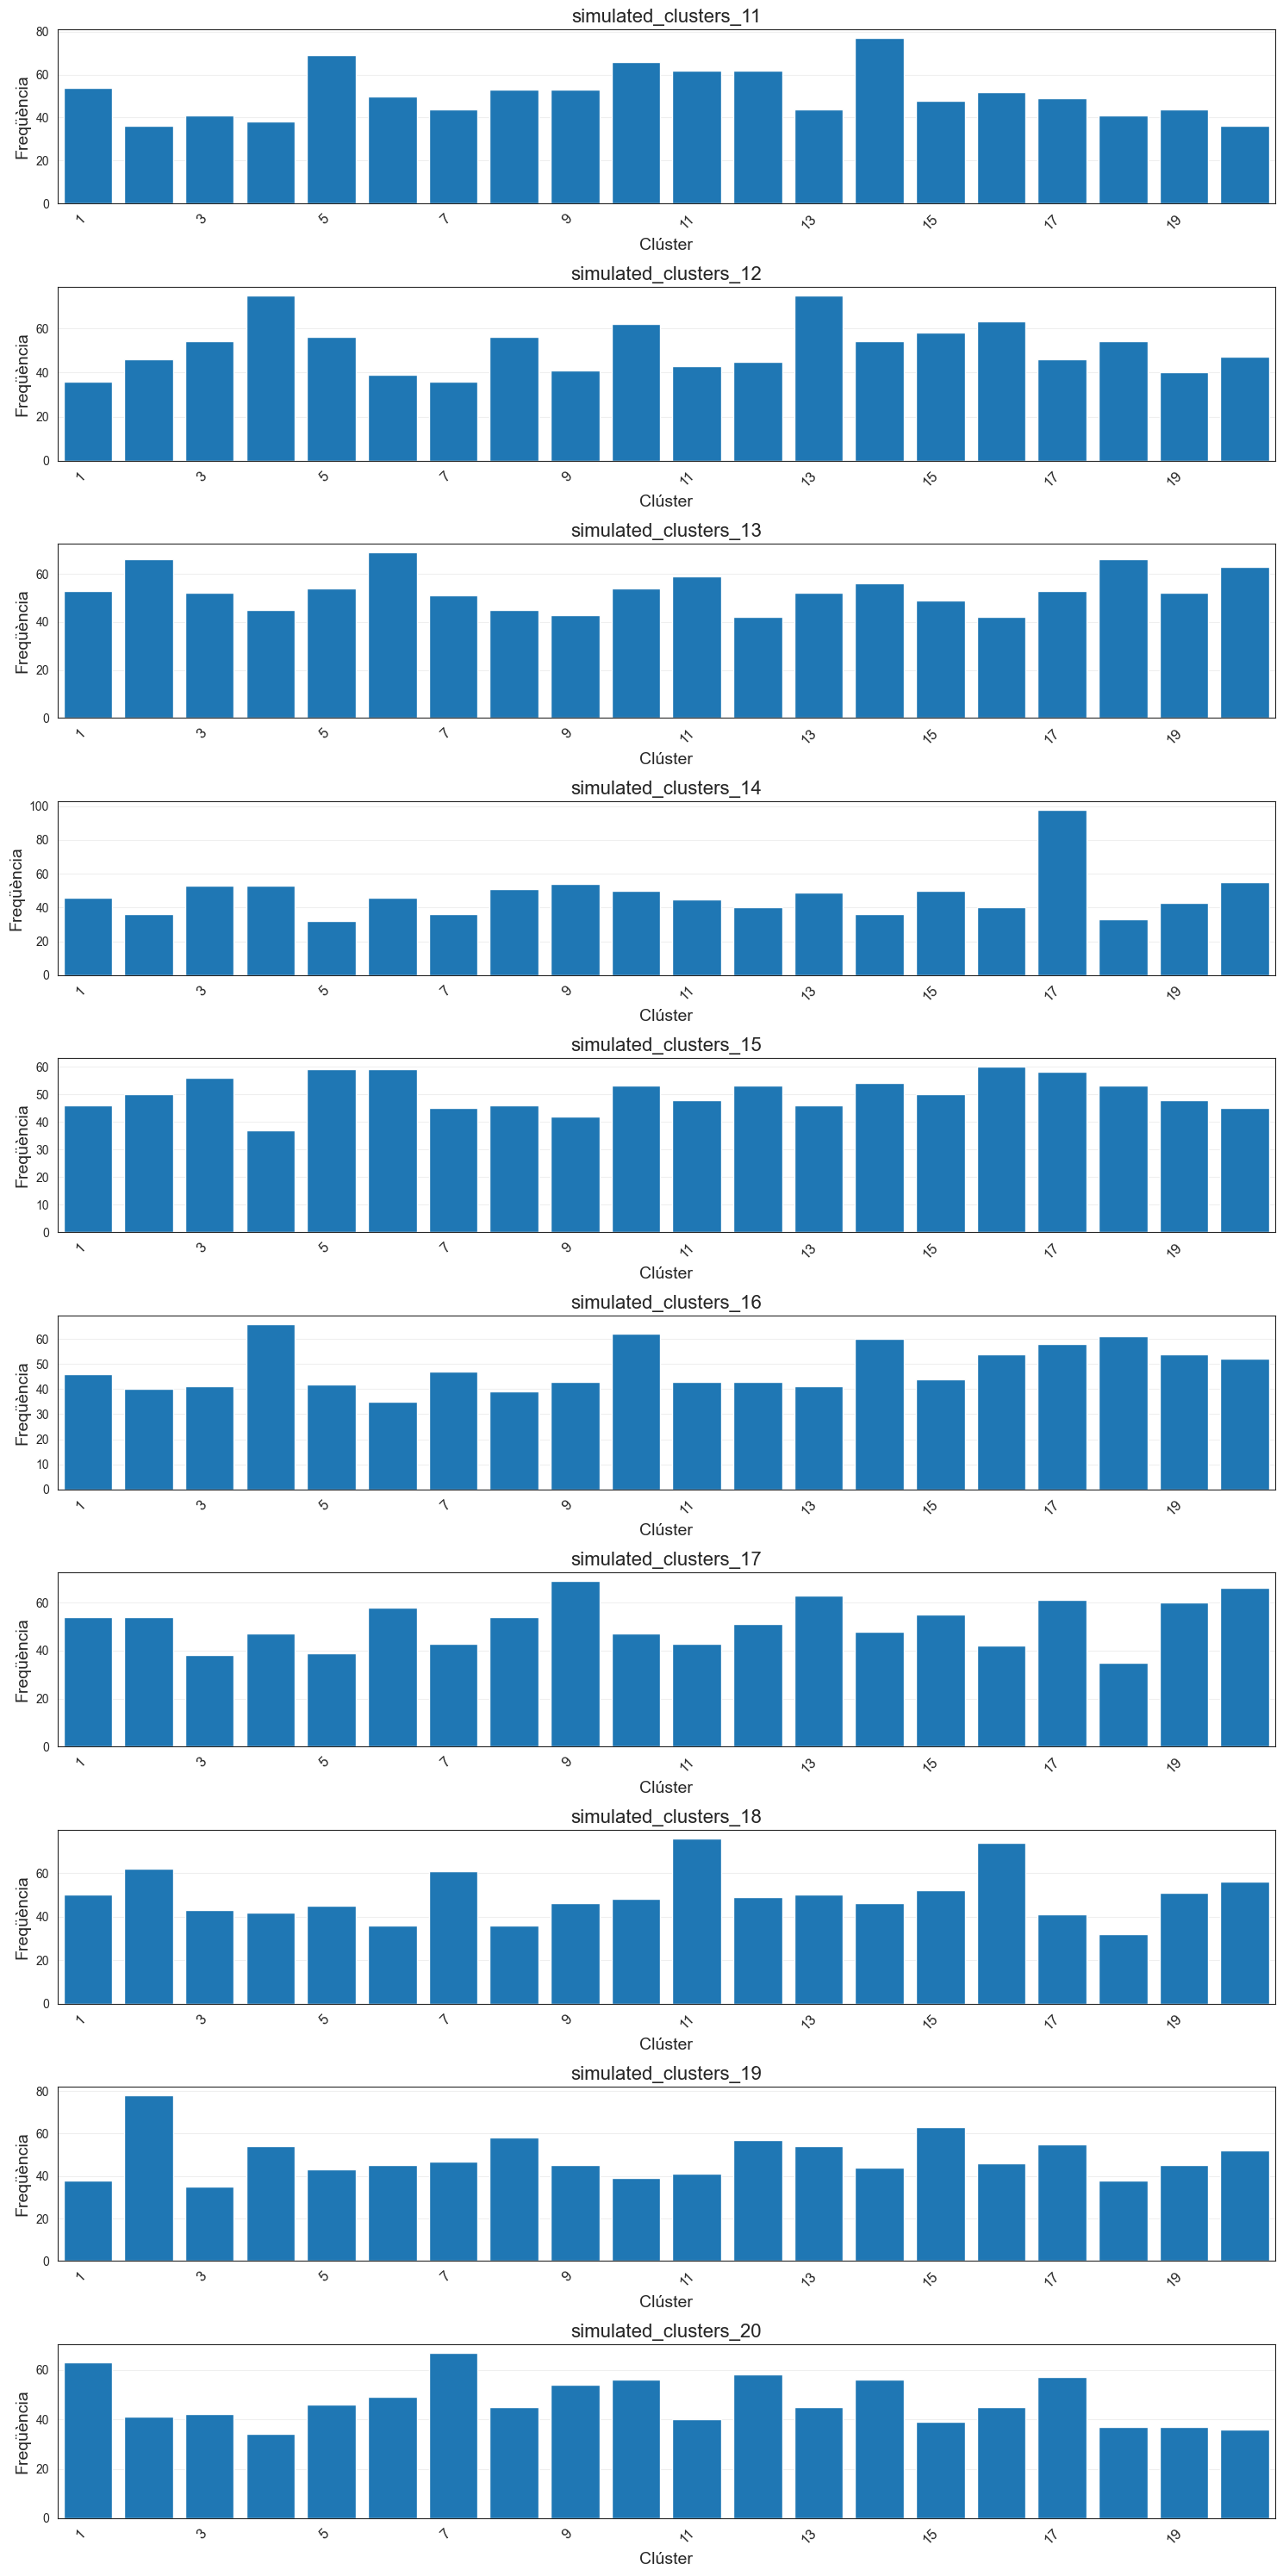

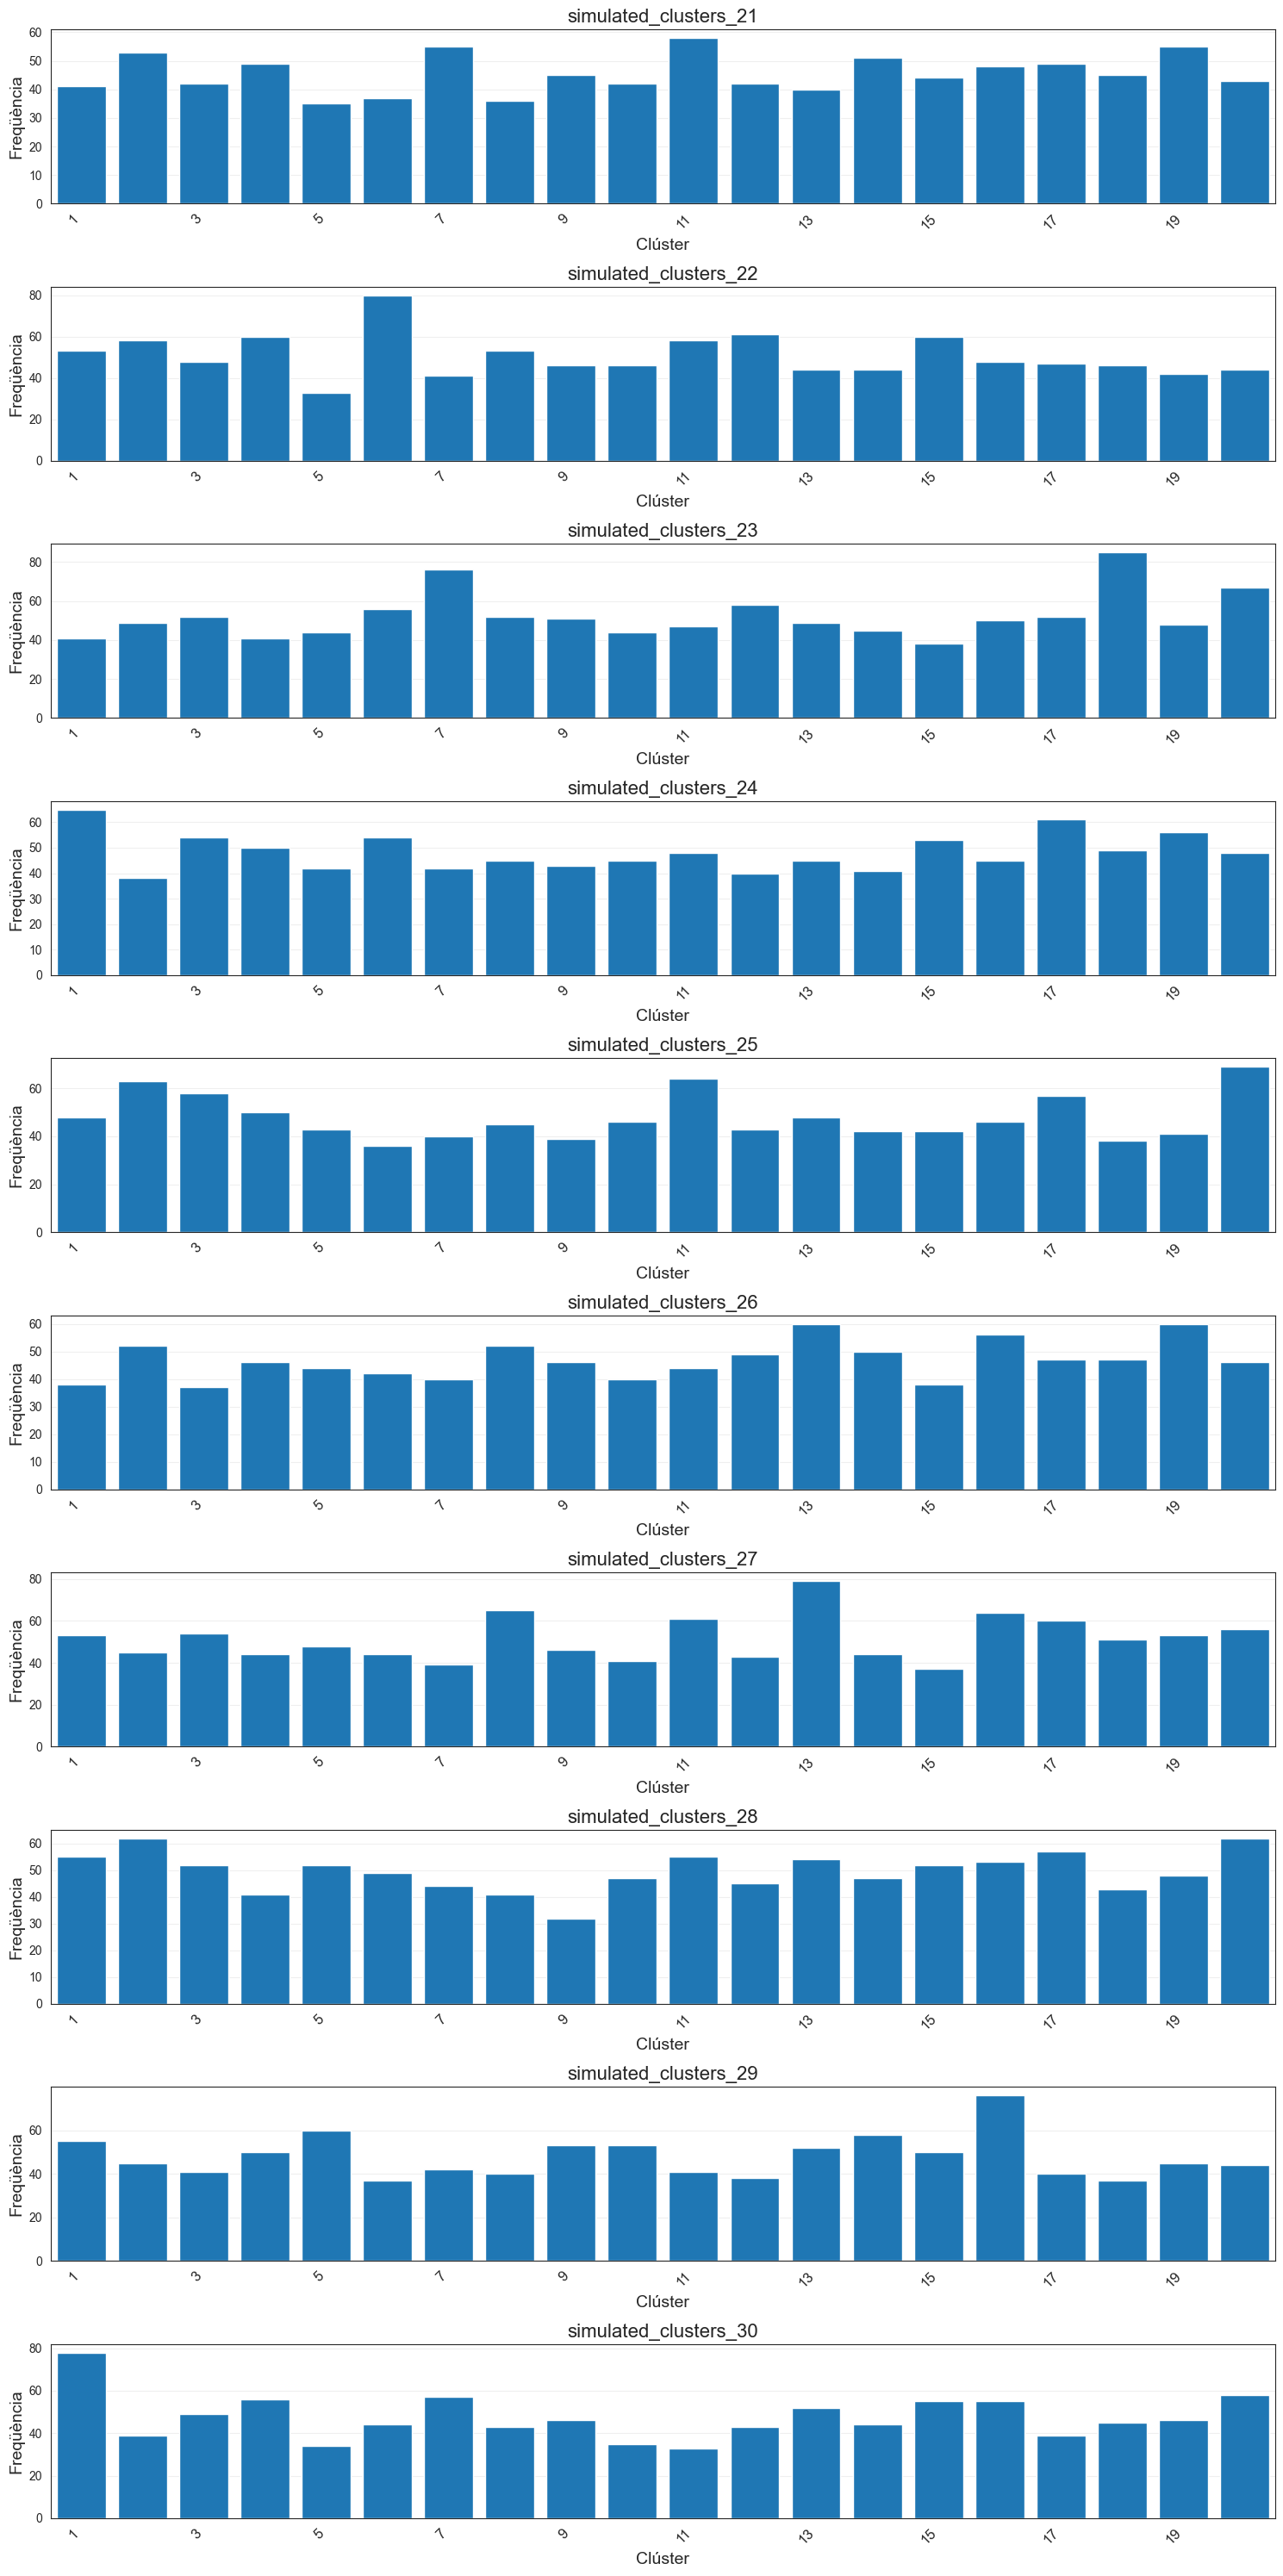

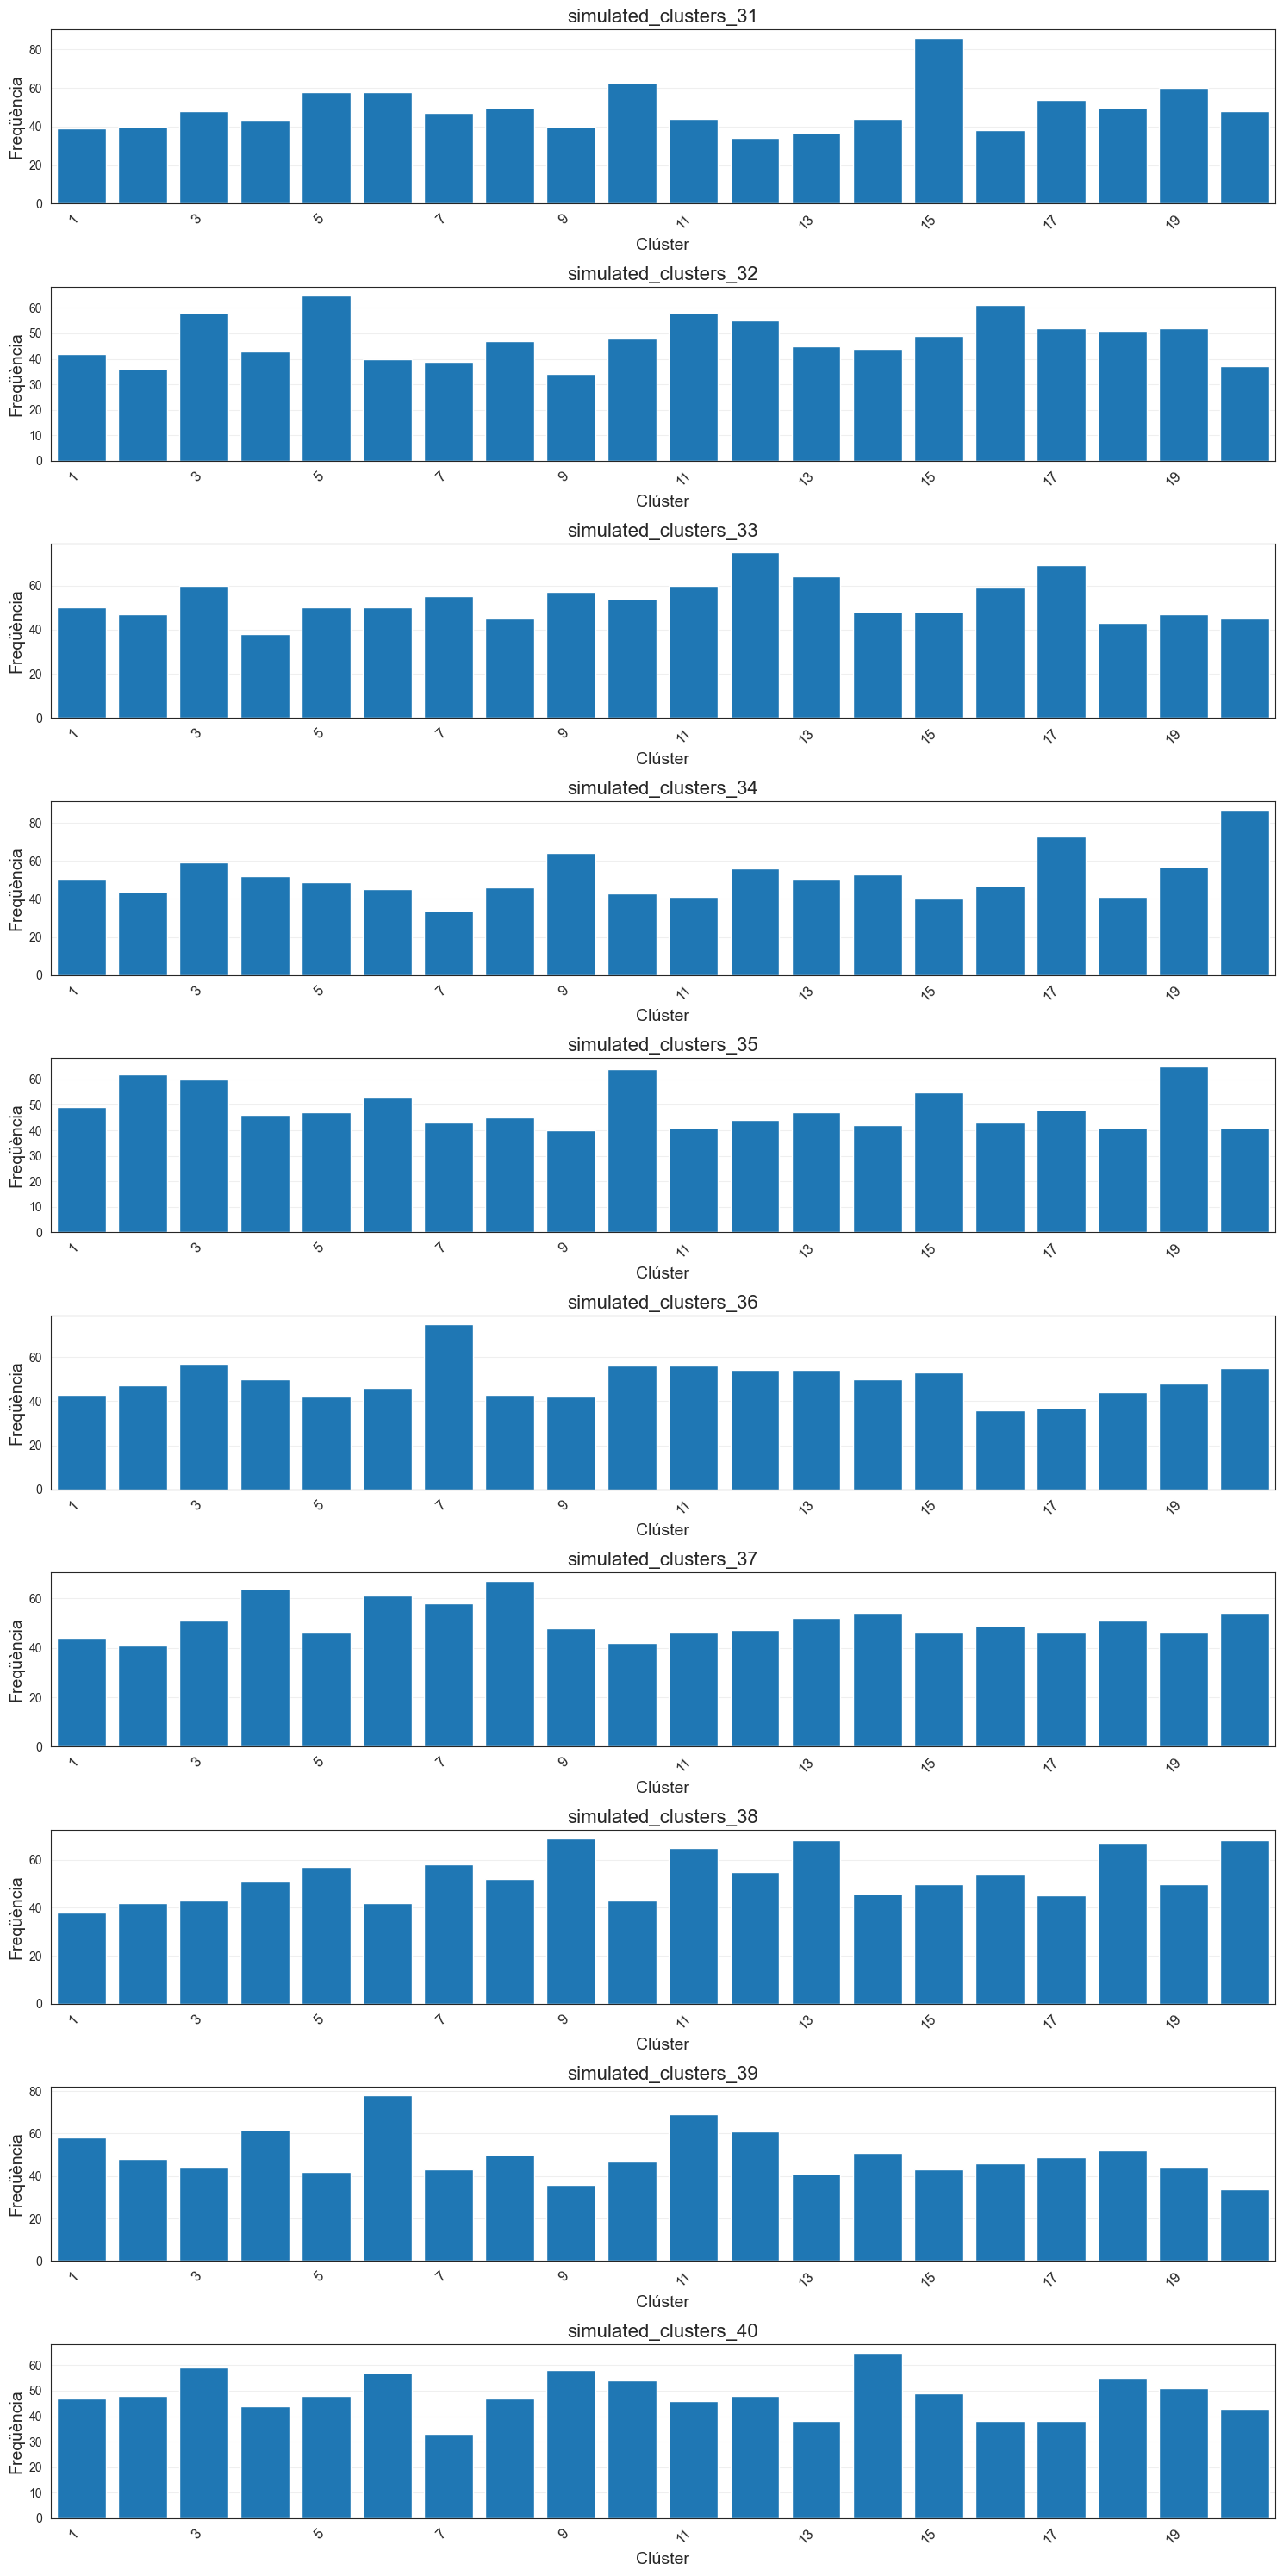

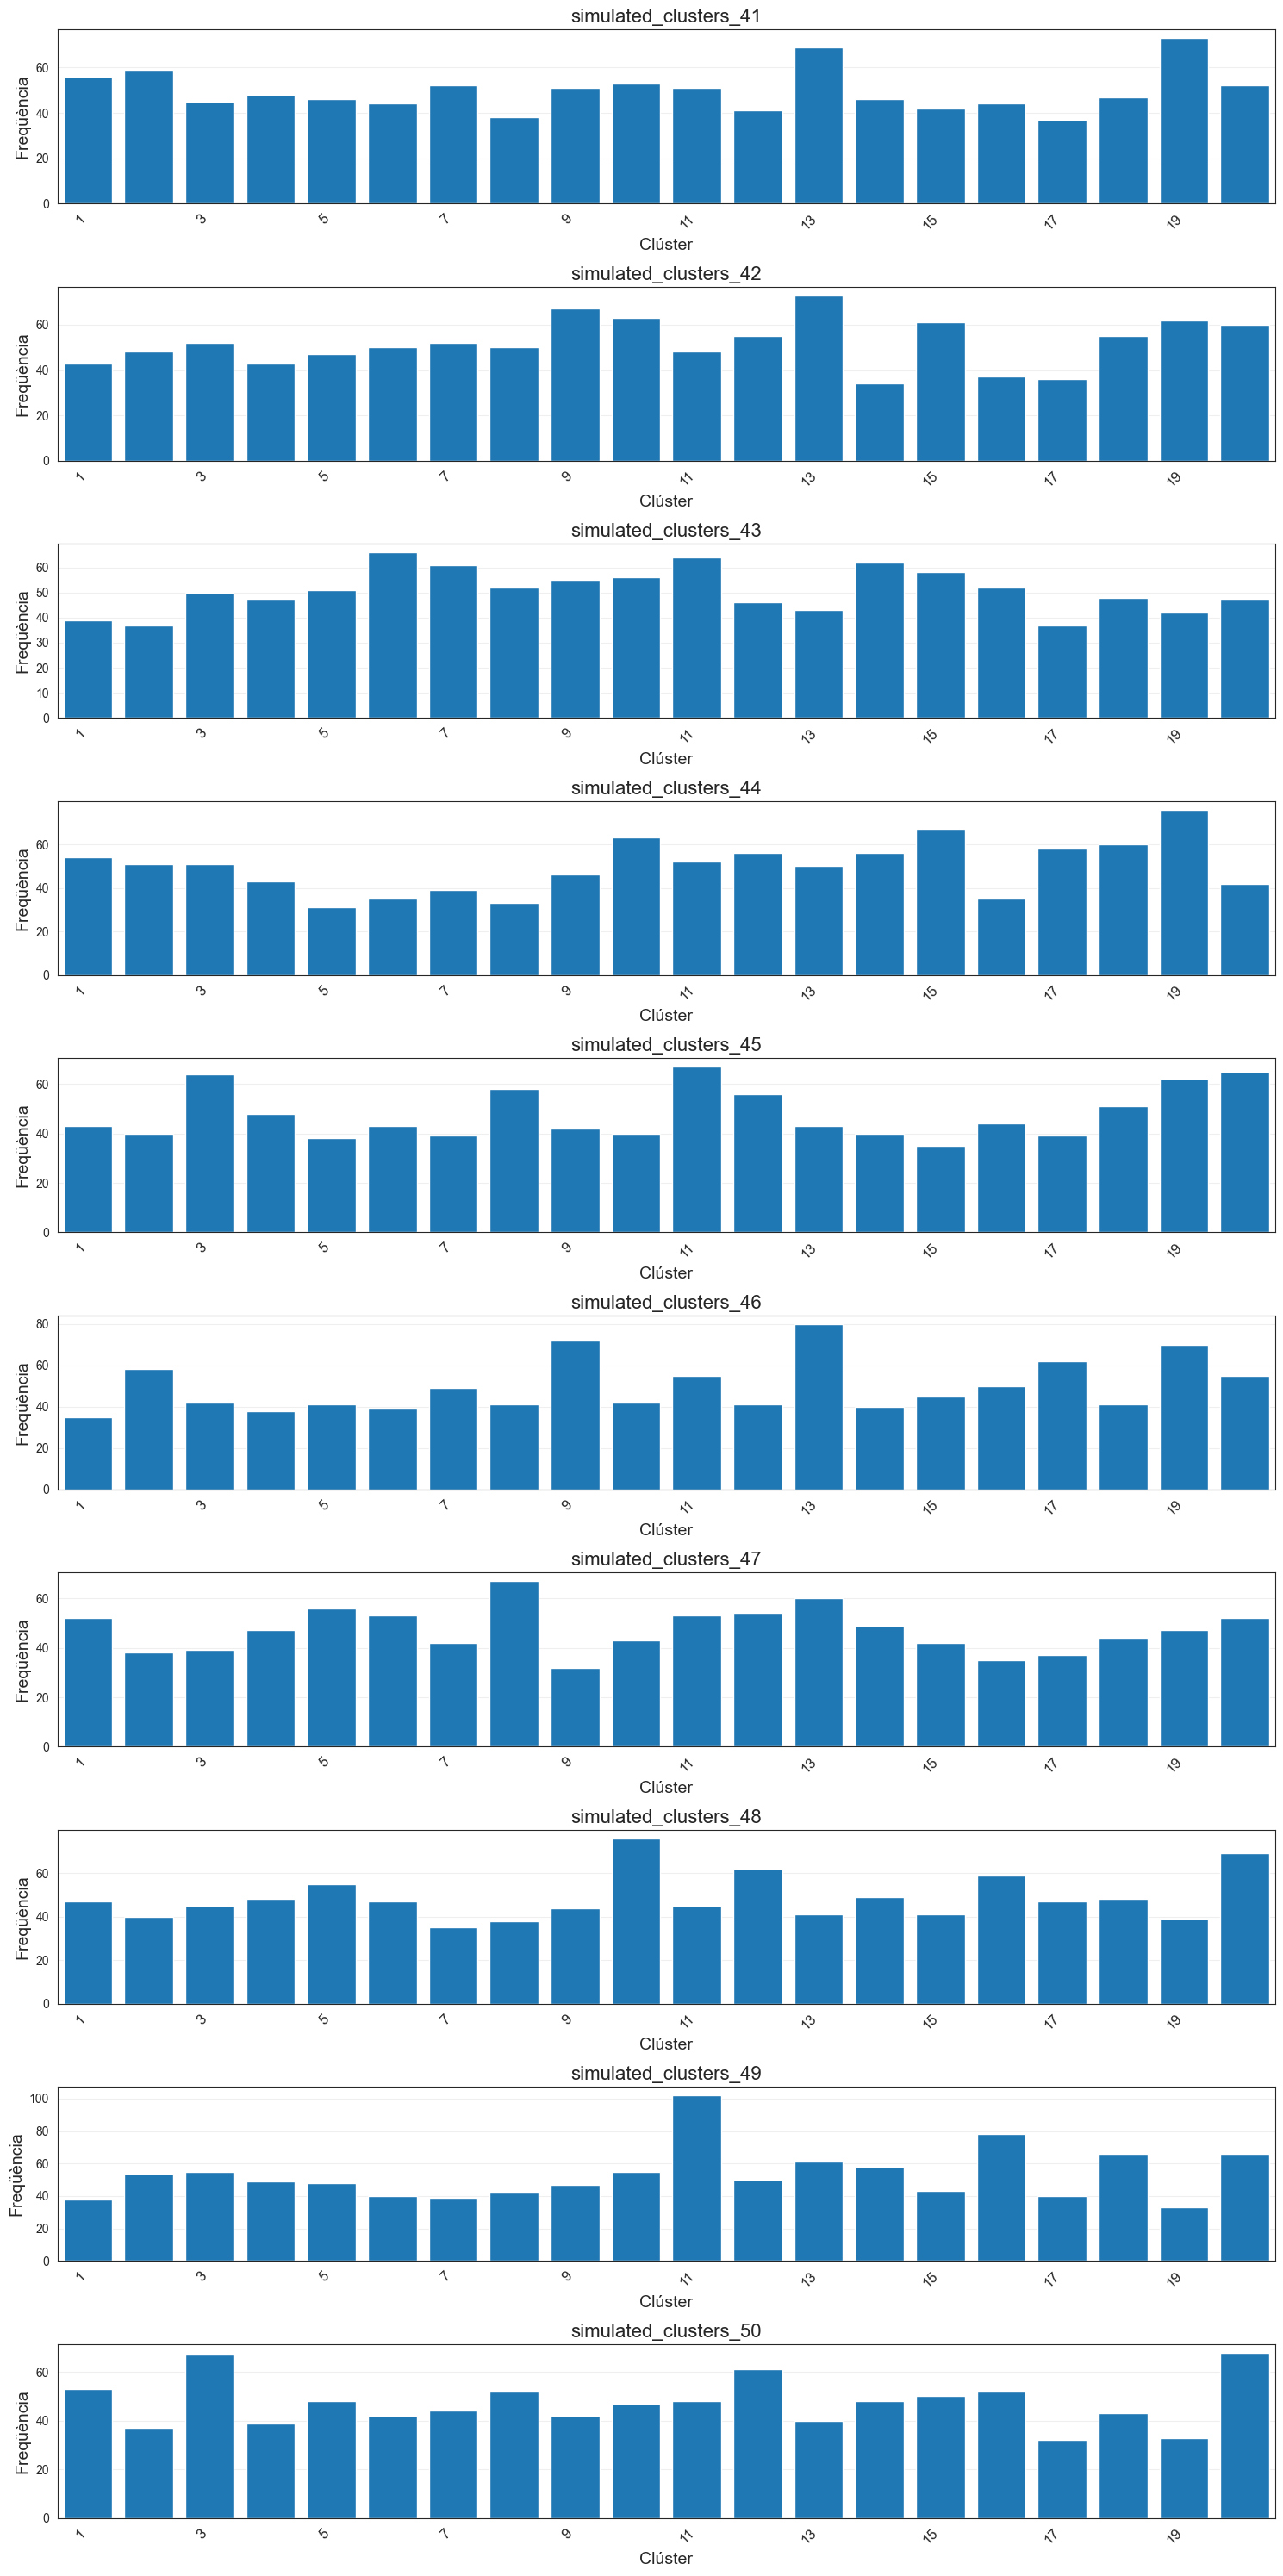

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

path = Path.cwd() / "csv_generats"

def extract_number(filename):
    match = re.search(r"\d+", filename.stem)
    return int(match.group()) if match else float("inf")

csv_files = sorted(path.glob("*.csv"), key=extract_number)

col_cluster = "index"

# --- Dividir en blocs de 10 ---
def chunks(lst, n):
    """Divide lst into chunks of size n."""
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

# --- Bucle principal ---
for group in chunks(csv_files, 10):

    fig, axes = plt.subplots(len(group), 1, figsize=(15, 3 * len(group)))
    axes = axes.flatten()

    for ax, csv_file in zip(axes, group):

        df = pd.read_csv(csv_file)
        df_filtrat = df[df[col_cluster] != 0]

        counts = df_filtrat[col_cluster].value_counts().sort_index()

        positions = counts.index
        ax.bar(positions, counts.values, align="center")

        ax.set_xlim(counts.index.min() - 0.5, counts.index.max() + 0.5)

        
        ax.set_title(csv_file.stem, fontsize=16)

        ax.set_xlabel("Clúster", fontsize=14)
        ax.set_ylabel("Freqüència", fontsize=14)

        ax.set_xticks(positions[::2])
        ax.set_xticklabels(positions[::2], rotation=45, ha="right", fontsize=12)

        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


Next, we load the training data and extract a small set of representative clusters for training. 

One of **MIRO**’s key advantages is its ability to learn effectively from limited data, typically requiring only a few dozen well-chosen clusters to generalize successfully.

In this tutorial, we use clusters extracted from just 3 out of the 50 available images in the dataset.

In [ ]:
import re

csv_files = sorted(path.glob("*.csv"), key=lambda x: int(re.findall(r'\d+', x.stem)[0]))
training_indices = [1,2,3,4,5]
training_paths = [csv_files[i - 1] for i in training_indices]
validation_paths = [path for path in csv_files if path not in training_paths]


## apply DBSCAN to test dataset, optimize parameters with OPTUNA
Make sure optimal parameters are stable

In [ ]:
from sklearn.cluster import DBSCAN

import optuna
import os
import csv

def objective_dbscan(trial):

    save_dir = "resultats_f_optuna"
    os.makedirs(save_dir, exist_ok=True)

    save_pat_2 = os.path.join(save_dir, "DBSCAN_ARI_dagger_values.csv")
    
    if not os.path.exists(save_pat_2):
        with open(save_pat_2, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["trial", "ARI_dagger_values", "eps", "min_samples"])

    eps_2 = trial.suggest_float("eps", 25, 50)
    min_samples_2 = trial.suggest_int("min_samples", 5, 30)

    vresults_2 = []

    for i, vpath in enumerate(validation_paths):
        vdata_2 = pd.read_csv(vpath).copy()       
    
        clusters_db = DBSCAN(
            eps=eps_2,
            min_samples=min_samples_2,
        ).fit_predict(vdata_2[["x", "y"]]);

        vdata_2["clustering-predictions"] = clusters_db + 1
        vdata_2["set"] = i

        results = lib.calculate_few_metrics_for_experiments(vdata_2)


        vresults_2.append( results["JIc_values"].values)
        # vresults_2.append((results["ARI_dagger_values"].values + results["JIc_values"].values)/2)

    ari_dag_results = sum(c[0] for c in vresults_2)/len(vresults_2)

    with open(save_pat_2, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([trial.number, ari_dag_results, eps_2, min_samples_2])


    return ari_dag_results

In [50]:
import pandas as pd

study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(objective_dbscan, n_trials=50, show_progress_bar=False)


print("Millors paràmetres DBSCAN:", study_dbscan.best_params)
print("Millor ARI_dagger_values:", study_dbscan.best_value)

[I 2026-04-27 20:11:56,154] A new study created in memory with name: no-name-0d963e4b-bc79-4c05-8bde-e0e0d613ba9f
[I 2026-04-27 20:11:59,659] Trial 0 finished with value: 0.4656613756613756 and parameters: {'eps': 29.475250715371743, 'min_samples': 25}. Best is trial 0 with value: 0.4656613756613756.
[I 2026-04-27 20:12:03,938] Trial 1 finished with value: 0.7460018403496664 and parameters: {'eps': 49.09067420797909, 'min_samples': 10}. Best is trial 1 with value: 0.7460018403496664.
[I 2026-04-27 20:12:07,946] Trial 2 finished with value: 0.8887493987493986 and parameters: {'eps': 35.16955860245672, 'min_samples': 15}. Best is trial 2 with value: 0.8887493987493986.
[I 2026-04-27 20:12:12,248] Trial 3 finished with value: 0.708272706359663 and parameters: {'eps': 49.19395746307555, 'min_samples': 9}. Best is trial 2 with value: 0.8887493987493986.
[I 2026-04-27 20:12:15,514] Trial 4 finished with value: 0.3025925925925926 and parameters: {'eps': 26.329783280824305, 'min_samples': 25}.

Millors paràmetres DBSCAN: {'eps': 33.482083757025315, 'min_samples': 17}
Millor ARI_dagger_values: 0.9085714285714289


In [52]:
results_df, experiments_df = lib.evaluate_dbscan_best_on_validation_paths(
    validation_paths=validation_paths,
    study_dbscan=study_dbscan,
)



for col in [ "ARI_values", "ARI_c_values", "ARI_dagger_values", "AMI_values", "JIc_values", "RMSRE_N_values", "RMSE_centr_values"]:
    print(f"{col}: {results_df[col].mean():.4f} ± {results_df[col].std():.4f}")


100%|██████████| 45/45 [00:00<00:00, 60.45it/s]


ARI_values: 0.8835 ± 0.0279
ARI_c_values: 0.8483 ± 0.0707
ARI_dagger_values: 0.8638 ± 0.0296
AMI_values: 0.8849 ± 0.0217
JIc_values: 0.9086 ± 0.0657
RMSRE_N_values: 0.2709 ± 0.1507
RMSE_centr_values: 2.5351 ± 0.4846


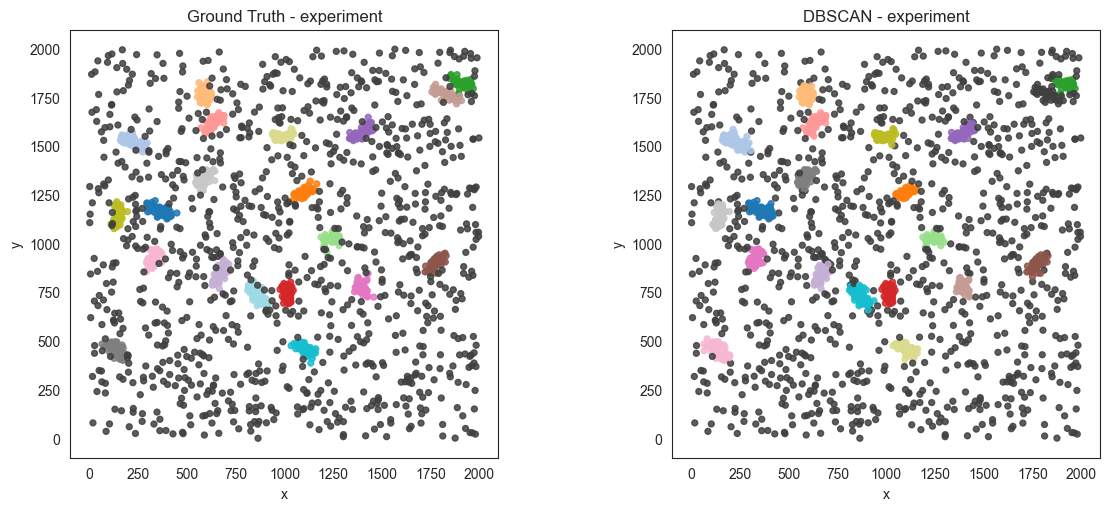

In [23]:
import matplotlib.pyplot as plt
import numpy as np


def _labels_to_colors(labels, zero_label=0, cmap_name="tab20"):
    """
    Map integer labels to colors, with `zero_label` shown in dark gray.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    cmap = plt.get_cmap(cmap_name, max(len(unique_labels), 1))
    color_map = {}

    non_zero_labels = [lab for lab in unique_labels if lab != zero_label]
    for i, lab in enumerate(sorted(non_zero_labels)):
        color_map[lab] = cmap(i)

    if zero_label in unique_labels:
        color_map[zero_label] = (0.25, 0.25, 0.25, 1.0)  # dark gray RGBA

    return [color_map[lab] for lab in labels]

def plot_experiment_gt_vs_pred(
    experiments_df,
    experiment_id,
    x_col="x",
    y_col="y",
    gt_col="index",
    pred_col="clustering-predictions",
    title_method="Predicted",
    point_size=18,
    alpha=0.85,
    zero_label=0,
):
    """
    Plot one experiment: GT on the left, predicted clustering on the right.
    Points with cluster/index == 0 are shown in gray.
    """

    exp = experiments_df[experiments_df["set"] == experiment_id].copy()
    if exp.empty:
        raise ValueError(f"No rows found for experiment_id={experiment_id}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # GT
    gt_colors = _labels_to_colors(exp[gt_col].values, zero_label=zero_label)
    axes[0].scatter(
        exp[x_col],
        exp[y_col],
        c=gt_colors,
        s=point_size,
        alpha=alpha,
    )
    axes[0].set_title(f"Ground Truth - experiment")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)
    axes[0].set_aspect("equal", adjustable="box")

    # Prediction
    pred_colors = _labels_to_colors(exp[pred_col].values, zero_label=zero_label)
    axes[1].scatter(
        exp[x_col],
        exp[y_col],
        c=pred_colors,
        s=point_size,
        alpha=alpha,
    )
    axes[1].set_title(f"{title_method} - experiment")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel(y_col)
    axes[1].set_aspect("equal", adjustable="box")

    plt.show()

plot_experiment_gt_vs_pred(
    experiments_df=experiments_df,
    experiment_id=3,
    title_method="DBSCAN",
)

### **2. Build the training dataset**


**MIRO** employs an augmentation pipeline that transforms the small set of training cluster into a large number of diverse point clouds for training. 

Each point cloud is generated by applying a series of transformations to randomly selected clusters, including geometric transformations (rotations, reflections), stochastic perturbations (localization dropout or addition), and spatial jitter (small random displacements).  These transformed clusters are then randomly placed within a synthetic FOV to generate the final training samples.


The following code initializes the **MIRO** data builder, which generates the augmented training dataset based on the extracted clusters and a set of metadata parameters. These metadata settings define key aspects of the synthetic dataset, such as the number of generated samples, the range of background noise points, the number of clusters per FOV, and the spatial connectivity radius used to define cluster compactness. 

You can inspect these settings by printing `metadata["builder_kwargs"]`. Once initialized, calling the builder returns a fully augmented dataset ready for training.


In [7]:
import pandas as pd


training_clusters, training_backgrounds = [], []
for csv_path in training_paths:
    df = pd.read_csv(csv_path)

    # Normalize coordinates to [0, 1]
    coords = df[["x", "y"]]
    mins, maxs = coords.min(), coords.max()
    df[["x", "y"]] = (coords - mins) / (maxs - mins)

    # Group by 'index'
    for idx, group in df.groupby("index"):
        # 0 (the background)
        if idx == 0:
            training_backgrounds.append(group[["x", "y"]].values)
        else:
            centered = group[["x", "y"]] - group[["x", "y"]].mean()
            training_clusters.append(centered)


In [8]:
metadata = {
    "csv_generats": {
        "training_indices": list(range(1, 6)),
        "builder": "GraphDataset",
        "builder_kwargs": {
            "dataset_size": 1500,
            "noise_point_range": [450, 550],
            "cluster_count_range": [10, 20],
            "connectivity_radius": 0.2,
        },

        "recurrent_iterations": 15,
        "checkpoint": "checkpoint.pt",
    }
}


metadata = metadata[path.name]

In [9]:

from pathlib import Path
import pickle

# ---- cache control ----
DATA_CACHE_PATH = Path("augmented_dataset.pkl")
LOAD_IF_AVAILABLE = True   # if True, load from disk when possible
FORCE_REGENERATE = True   # if True, ignore cache and rebuild

# Initialize the MIRO builder with the training clusters and metadata
builder_args = (training_clusters,)
if BLINKING:
    builder_args += (training_backgrounds,)

builder = getattr(lib, metadata["builder"])(
    *builder_args, **metadata["builder_kwargs"]
)

# Decide whether to load or generate
if LOAD_IF_AVAILABLE and DATA_CACHE_PATH.exists() and not FORCE_REGENERATE:
    print(f"Loading dataset from {DATA_CACHE_PATH}")
    with open(DATA_CACHE_PATH, "rb") as f:
        augmented_dataset = pickle.load(f)
else:
    print("Generating dataset...")
    augmented_dataset = builder()

    print(f"Saving dataset to {DATA_CACHE_PATH}")
    with open(DATA_CACHE_PATH, "wb") as f:
        pickle.dump(augmented_dataset, f)

  0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset...


Generating dataset:   0%|          | 0/1500 [00:00<?, ?it/s]

Saving dataset to augmented_dataset.pkl


Let’s take a closer look at one of the augmented training images.

In **MIRO**, each training sample is represented as a **graph**, where nodes correspond to individual molecular localizations and edges are defined via Delaunay triangulation to capture local spatial relationships. You can use the following code to visualize one of these examples.

The colormap in the labeled scatter plot represents the magnitude of the **displacement vectors** from each node to its assigned cluster center. These vectors serve as the ground truth during training, enabling **MIRO** to learn transformations that contract structures toward a common center, effectively modeling the underlying cluster geometry.


In [226]:
import numpy as np
import matplotlib.pyplot as plt

def plot_training_data(sample_idx):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    data = augmented_dataset[sample_idx]

    # Plot the graph representation
    for edge in data["edge_index"].T:
        x = [data["position"][edge[0]][0], data["position"][edge[1]][0]]
        y = [data["position"][edge[0]][1], data["position"][edge[1]][1]]
        ax[0].plot(x, y, color="black", linewidth=0.5, alpha=0.3)

    ax[0].scatter(
        data["position"][:, 0],
        data["position"][:, 1],
        s=10,
        zorder=2,
        c="orange",
        edgecolors="black",
    )
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[0].set_title("Input Graph", fontsize=16)

    # Ground Truth with viridis colormap (blue → yellow)
    ax[1].scatter(
        data["position"][:, 0],
        data["position"][:, 1],
        c=np.linalg.norm(data["y"], axis=1),
        s=10,
        cmap="viridis"
    )
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_title("Ground Truth", fontsize=16)

    plt.subplots_adjust(wspace=0.02)
    plt.show()


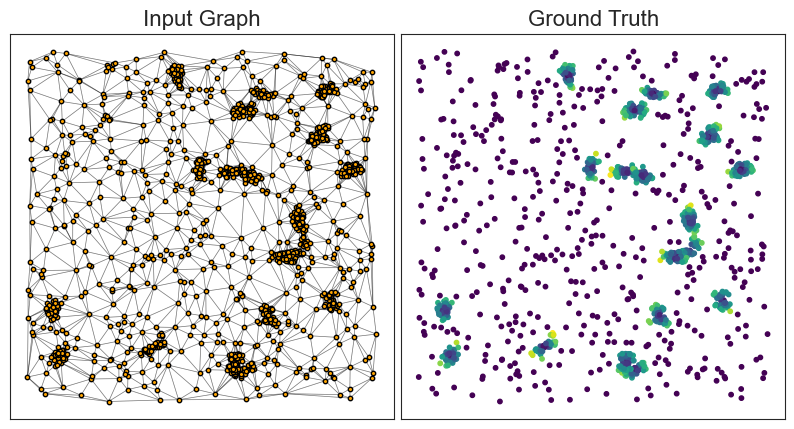

In [227]:
if True:
    random_sample_idx = np.random.randint(0, len(augmented_dataset))
    plot_training_data(random_sample_idx)

### **3. Create the model**


Now, instantiate **MIRO** using the configuration that matches the training data. 

The model is initialized with a set of key parameters: the number of output features (in this case, 2 for the predicted *x* and *y* displacements), the connectivity radius used to construct the input graphs (which should match the one used during augmentation), and the number of recurrent message-passing iterations to apply on the input graphs (set to 20 by default).

In [12]:
import deeplay as dl

clusterer = dl.MIRO(
    num_outputs=2,  # Number of output features (e.g., x, y displacements)
    connectivity_radius=builder.connectivity_radius,  # Radius for graph connectivity (matches dataset)
    num_iterations=metadata["recurrent_iterations"],  # Number of iterations for graph processing
)
clusterer = clusterer.create()

print(clusterer)

MIRO(
  (model): RecurrentMessagePassingModel(
    (encoder): Parallel(
      (0-1): 2 x MultiLayerPerceptron(
        (blocks): LayerList(
          (0): LinearBlock(
            (layer): LazyLinear(in_features=0, out_features=256, bias=True)
            (activation): Identity()
          )
        )
      )
    )
    (backbone): RecurrentGraphBlock(
      (combine): CatDictElements()
      (layer): Sequential(
        (0): Parallel(
          (0-1): 2 x MultiLayerPerceptron(
            (blocks): LayerList(
              (0): LinearBlock(
                (layer): LazyLinear(in_features=0, out_features=256, bias=True)
                (activation): Identity()
              )
            )
          )
        )
        (1): MessagePassingNeuralNetwork(
          (blocks): LayerList(
            (0): TransformPropagateUpdate(
              (transform): Transform(
                (combine): Cat()
                (layer): LazyLinear(in_features=0, out_features=256, bias=True)
             

### **4. Train the model**


Set up the data loaders and configure the training parameters.

In [81]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    dataset=augmented_dataset,  # The dataset to be loaded
    batch_size=4,  # Number of samples per batch
    shuffle=True,  # Shuffle the dataset at every epoch
)

# Initialize the trainer
trainer = dl.Trainer(max_epochs=30)  # Maximum number of training epochs

Finally, train **MIRO**. 

Alternatively, you can load a pre-trained model by setting `train_model = False`.

In [ ]:
import torch

train_model = False

if train_model:
    trainer.fit(
        clusterer,  # The MIRO model to be trained
        train_loader,  # The DataLoader providing the training data
    )
else:
   clusterer = type(clusterer).load_from_checkpoint("lightning_logs/version_2/checkpoints/epoch=29-step=45000.ckpt", map_location="cpu")
   clusterer.to(torch.device('cpu'))
   clusterer.eval()


## 4.1 Representació per veure si MIRO està fent veritablement l'entrenament

In [212]:
def compare_before_after(sample_idx, model, dataset):
    model.eval()
    
    data = dataset[sample_idx]

    pos = data.position.numpy()
    edges = data.edge_index.numpy()
    y_true = data.y.numpy()

    # Predicció del model
    with torch.no_grad():
        out = model(data)

        if isinstance(out, list):
            pred = out[0]   
        else:
            pred = out

        pred = pred.detach().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # INPUT
    for edge in edges.T:
        x = [pos[edge[0]][0], pos[edge[1]][0]]
        y = [pos[edge[0]][1], pos[edge[1]][1]]
        ax[0].plot(x, y, color="black", linewidth=0.5, alpha=0.3)

    ax[0].scatter(pos[:, 0], pos[:, 1], s=10, c="orange")
    ax[0].set_title("Input Graph", fontsize=16)

    # GROUND TRUTH (blau → groc)
    ax[1].scatter(
        pos[:, 0],
        pos[:, 1],
        c=np.linalg.norm(y_true, axis=1),
        cmap="viridis",
        s=10
    )
    ax[1].set_title("Ground Truth", fontsize=16)

    # PREDICCIÓ (blau → groc)
    ax[2].scatter(
        pos[:, 0],
        pos[:, 1],
        c=np.linalg.norm(pred, axis=1),
        cmap="viridis",
        s=10
    )
    ax[2].set_title("Model Prediction", fontsize=16)

    for a in ax:
        a.set_xticks([])
        a.set_yticks([])

    plt.tight_layout()
    plt.show()


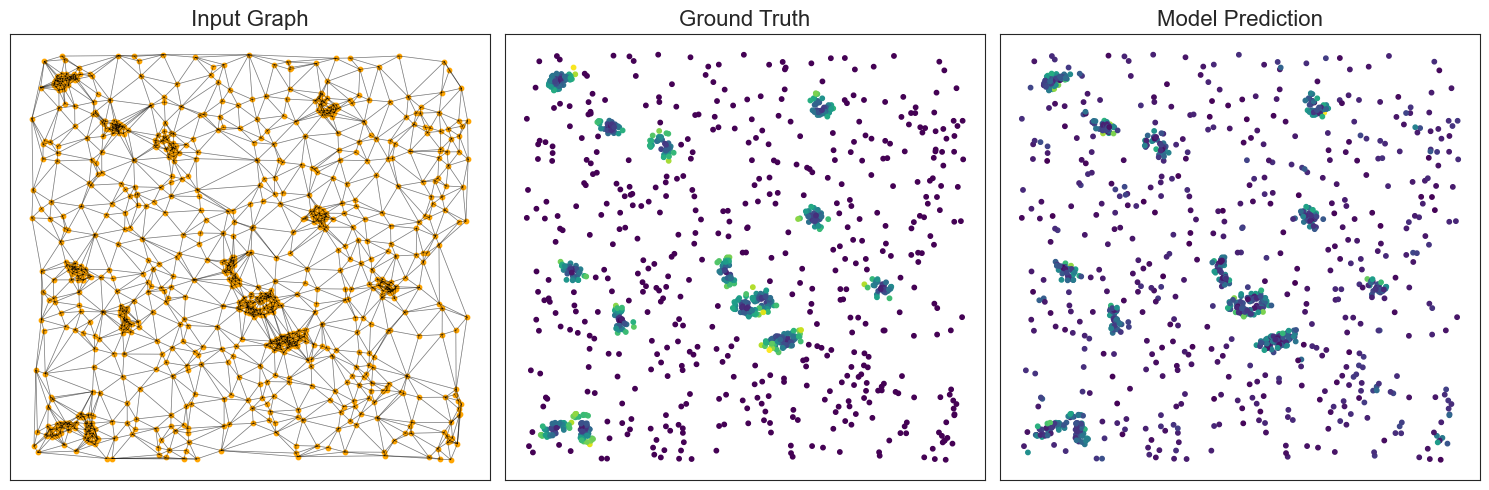

In [213]:
compare_before_after(
    sample_idx=100,
    model=clusterer,
    dataset=augmented_dataset
)

### **5. Test the model**


Once training is complete, it’s time to evaluate **MIRO** on the validation dataset.

The following code reads the validation set and applies the trained model to perform clustering. The `clusterer` object includes a built-in `.clustering()` method, which automates the full inference pipeline. This method applies MIRO to each input graph, transforms the node features into the learned **squeezed representation** (where localizations belonging to the same cluster are pulled toward a common center) and runs DBSCAN on this transformed space to produce the final cluster assignments.


### 5.1 Funció otpuna per MIRO

In [ ]:
from attrs import inspect
from sklearn.cluster import DBSCAN

clusterer.eval()
clusterer.to("cuda" if torch.cuda.is_available() else "cpu")

# validation_paths = [path for path in csv_files if path not in training_paths]

# import optuna
# import os
# import csv

def objective_miro(trial):

    save_dir = "resultats_f_optuna"
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, "MIRO_ARI_dagger_values.csv")
    
    if not os.path.exists(save_path):
        with open(save_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["trial", "ARI_dagger_values", "eps", "min_samples"])

    eps = trial.suggest_float("eps", 5, 25)
    min_samples = trial.suggest_int("min_samples", 5, 30)

    vresults = []

    for i, vpath in enumerate(validation_paths):
        vdata = pd.read_csv(vpath).copy() 
        val_graph = lib.compute_test_graph(vdata, builder)      
    
        clusters_miro = clusterer.clustering(
            val_graph,
            eps=eps,
            min_samples=min_samples,
            scaling=vdata[["x", "y"]].max().values,)

        vdata["clustering-predictions"] = clusters_miro + 1
        vdata["set"] = i

        results = lib.calculate_few_metrics_for_experiments(vdata)

        vresults.append(results["JIc_values"].values)
        # vresults.append((results["ARI_dagger_values"].values + results["JIc_values"].values)/2)


    ari_dag_results = sum(c[0] for c in vresults)/len(vresults)

    with open(save_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([trial.number, ari_dag_results,eps, min_samples])


    return ari_dag_results

In [ ]:
import optuna
import os
import csv

study_miro = optuna.create_study(direction="maximize")
study_miro.optimize(objective_miro, n_trials=50, show_progress_bar=False)

print("Millors paràmetres MIRO:", study_miro.best_params)
print("Millor ARI_dagger_values:", study_miro.best_value)

[I 2026-04-27 17:33:40,582] A new study created in memory with name: no-name-7f842084-54be-4cf6-96a7-f5bbab26714f
[I 2026-04-27 17:36:30,855] Trial 0 finished with value: 0.9481240981240977 and parameters: {'eps': 6.5463594836861905, 'min_samples': 9}. Best is trial 0 with value: 0.9481240981240977.
[I 2026-04-27 17:39:21,157] Trial 1 finished with value: 0.9544444444444445 and parameters: {'eps': 22.125243624031917, 'min_samples': 30}. Best is trial 1 with value: 0.9544444444444445.
[I 2026-04-27 17:42:11,122] Trial 2 finished with value: 0.925694000041826 and parameters: {'eps': 5.007473787840304, 'min_samples': 15}. Best is trial 1 with value: 0.9544444444444445.
[I 2026-04-27 17:44:23,434] Trial 3 finished with value: 0.9529100529100529 and parameters: {'eps': 12.082836879787548, 'min_samples': 12}. Best is trial 1 with value: 0.9544444444444445.
[I 2026-04-27 17:46:29,661] Trial 4 finished with value: 0.9396151996151997 and parameters: {'eps': 12.539028548886268, 'min_samples': 9}

KeyboardInterrupt: 

In [53]:
results_df2, experiments_df2 = lib.evaluate_dbscan_best_on_validation_paths(
    validation_paths=validation_paths,
    study_dbscan=study_miro,
    clusterer=clusterer,
    builder=builder,
)

print("\nDBSCAN results:")

for col in [ "ARI_values", "ARI_c_values", "ARI_dagger_values", "AMI_values", "JIc_values", "RMSRE_N_values", "RMSE_centr_values"]:
    print(f"{col}: {results_df[col].mean():.4f} ± {results_df[col].std():.4f}")

print("\nMIRO results:")

for col in [ "ARI_values", "ARI_c_values", "ARI_dagger_values", "AMI_values", "JIc_values", "RMSRE_N_values", "RMSE_centr_values"]:
    print(f"{col}: {results_df2[col].mean():.4f} ± {results_df2[col].std():.4f}")


100%|██████████| 45/45 [02:03<00:00,  2.75s/it]



DBSCAN results:
ARI_values: 0.8835 ± 0.0279
ARI_c_values: 0.8483 ± 0.0707
ARI_dagger_values: 0.8638 ± 0.0296
AMI_values: 0.8849 ± 0.0217
JIc_values: 0.9086 ± 0.0657
RMSRE_N_values: 0.2709 ± 0.1507
RMSE_centr_values: 2.5351 ± 0.4846

MIRO results:
ARI_values: 0.8730 ± 0.0199
ARI_c_values: 0.9469 ± 0.0401
ARI_dagger_values: 0.8608 ± 0.0254
AMI_values: 0.8864 ± 0.0166
JIc_values: 0.9712 ± 0.0361
RMSRE_N_values: 0.1911 ± 0.0900
RMSE_centr_values: 2.2317 ± 0.2981


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def _labels_to_colors(labels, zero_label=0, cmap_name="tab20"):
    """
    Map integer labels to colors, with `zero_label` shown in dark gray.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    cmap = plt.get_cmap(cmap_name, max(len(unique_labels), 1))
    color_map = {}

    non_zero_labels = [lab for lab in unique_labels if lab != zero_label]
    for i, lab in enumerate(sorted(non_zero_labels)):
        color_map[lab] = cmap(i)

    if zero_label in unique_labels:
        color_map[zero_label] = (0.25, 0.25, 0.25, 1.0)  # dark gray RGBA

    return [color_map[lab] for lab in labels]

def plot_experiment_gt_dbscan_miro_with_zoom(
    experiments_df,
    experiment_id,
    x_col="x",
    y_col="y",
    gt_col="index",
    dbscan_col="clustering-predictions",
    miro_col="miro-predictions",
    point_size=18,
    alpha=0.85,
    zero_label=0,
    zoom_center=(1500, 1250),
    zoom_delta=200,
):
    exp = experiments_df[experiments_df["set"] == experiment_id].copy()
    if exp.empty:
        raise ValueError(f"No rows found for experiment_id={experiment_id}")

    # Colors
    gt_colors = _labels_to_colors(exp[gt_col].values, zero_label=zero_label)
    db_colors = _labels_to_colors(exp[dbscan_col].values, zero_label=zero_label)
    miro_colors = _labels_to_colors(exp[miro_col].values, zero_label=zero_label)

    # Zoom limits
    zx, zy = zoom_center
    x_min, x_max = zx - zoom_delta, zx + zoom_delta
    y_min, y_max = zy - zoom_delta, zy + zoom_delta

    # ============================================================
    #  FIGURA 1 — GT | DBSCAN | MIRO (sense zoom)
    # ============================================================
    
    fig1, ax1 = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    ax1[0].scatter(exp[x_col], exp[y_col], c=gt_colors, s=point_size, alpha=alpha)
    ax1[0].set_title("GT - experiment", fontsize=16)
    ax1[0].set_aspect("equal", adjustable="box")

    ax1[1].scatter(exp[x_col], exp[y_col], c=db_colors, s=point_size, alpha=alpha)
    ax1[1].set_title("DBSCAN - experiment", fontsize=16)
    ax1[1].set_aspect("equal", adjustable="box")

    ax1[2].scatter(exp[x_col], exp[y_col], c=miro_colors, s=point_size, alpha=alpha)
    ax1[2].set_title("MIRO - experiment", fontsize=16)
    ax1[2].set_aspect("equal", adjustable="box")

    plt.show()

    # ============================================================
    #  FIGURA 2 — GT | DBSCAN | MIRO (zoom in)
    # ============================================================

    fig2, ax2 = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    ax2[0].scatter(exp[x_col], exp[y_col], c=gt_colors, s=point_size, alpha=alpha)
    ax2[0].set_xlim(x_min, x_max)
    ax2[0].set_ylim(y_min, y_max)
    ax2[0].set_title("GT - zoom in", fontsize=16)
    ax2[0].set_aspect("equal", adjustable="box")

    ax2[1].scatter(exp[x_col], exp[y_col], c=db_colors, s=point_size, alpha=alpha)
    ax2[1].set_xlim(x_min, x_max)
    ax2[1].set_ylim(y_min, y_max)
    ax2[1].set_title("DBSCAN - zoom in", fontsize=16)
    ax2[1].set_aspect("equal", adjustable="box")

    ax2[2].scatter(exp[x_col], exp[y_col], c=miro_colors, s=point_size, alpha=alpha)
    ax2[2].set_xlim(x_min, x_max)
    ax2[2].set_ylim(y_min, y_max)
    ax2[2].set_title("MIRO - zoom in", fontsize=16)
    ax2[2].set_aspect("equal", adjustable="box")

    plt.show()


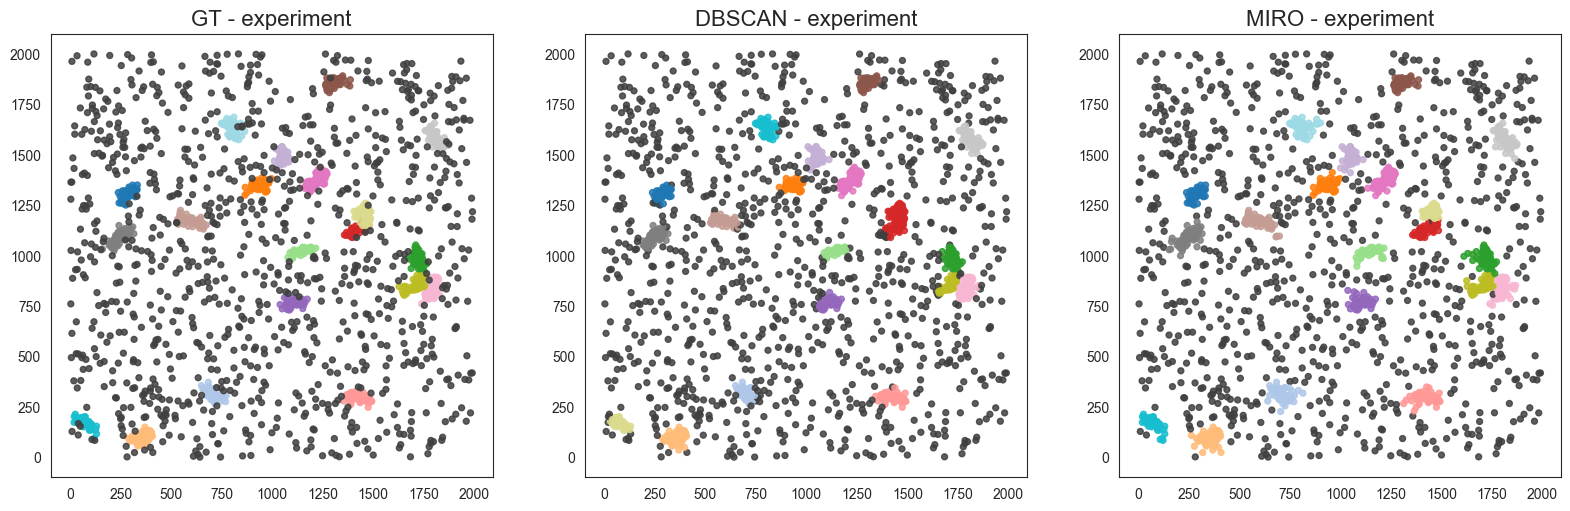

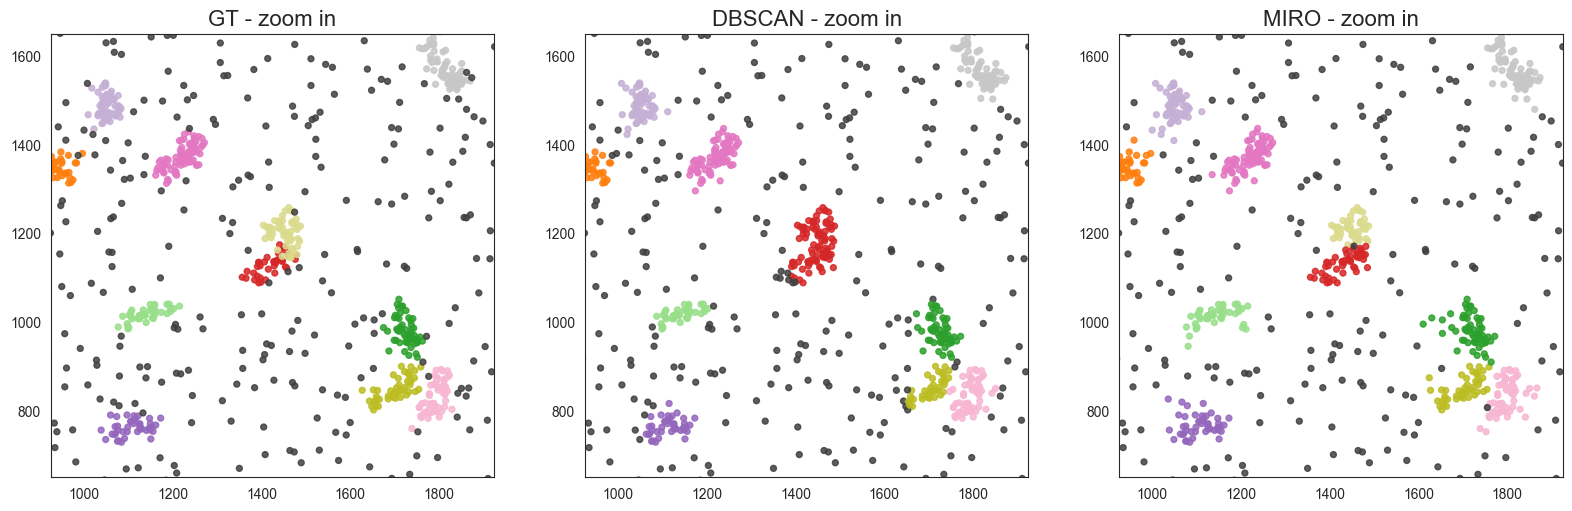

In [224]:
exp_id=6
df = experiments_df.copy()
df["miro-predictions"] = experiments_df2["clustering-predictions"]

plot_experiment_gt_dbscan_miro_with_zoom(
    experiments_df=df,
    experiment_id=exp_id,
    zoom_center=(1425, 1150),
    zoom_delta=500
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_boxplot_sidepoints_scaled(miro, db, metric_name, p_value):

    sns.set_style("white")

    data = pd.DataFrame({
        "valor": list(miro) + list(db),
        "Algoritme": ["MIRO"] * len(miro) + ["DBSCAN"] * len(db)
    })

    plt.figure(figsize=(6, 4))  # més compacte per fila

    colors = {
        "MIRO": "#4C72B0",
        "DBSCAN": "#55A868"
    }

    ax = plt.gca()

    # ============================
    #  POSICIONS COMPACTES
    # ============================
    x_positions = {"MIRO": 0, "DBSCAN": 0.6}
    offset = -0.22  # violin + punts a l'esquerra

    # ============================
    #  BOXPLOT (matplotlib)
    # ============================
    box = ax.boxplot(
        [
            data[data["Algoritme"] == "MIRO"]["valor"],
            data[data["Algoritme"] == "DBSCAN"]["valor"]
        ],
        positions=[x_positions["MIRO"], x_positions["DBSCAN"]],
        widths=0.16,
        patch_artist=True,
        showfliers=False
    )

    # colors boxplot
    for patch, alg in zip(box['boxes'], ["MIRO", "DBSCAN"]):
        patch.set_facecolor(colors[alg])
        patch.set_alpha(0.6)

    # mediana en vermell
    for median in box['medians']:
        median.set_color("#E57373")
        median.set_linewidth(2.2)

    # ============================
    #  VIOLIN DESPLAÇAT
    # ============================
    for alg in ["MIRO", "DBSCAN"]:
        vals = data[data["Algoritme"] == alg]["valor"]

        parts = ax.violinplot(
            vals,
            positions=[x_positions[alg] + offset],
            widths=0.18,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        for pc in parts['bodies']:
            pc.set_facecolor(colors[alg])
            pc.set_alpha(0.35)

    # ============================
    #  PUNTS (alineats amb violin)
    # ============================
    for alg in ["MIRO", "DBSCAN"]:
        vals = data[data["Algoritme"] == alg]["valor"]

        jitter = np.random.uniform(-0.035, 0.035, size=len(vals))
        x = np.ones(len(vals)) * (x_positions[alg] + offset) + jitter

        plt.scatter(
            x, vals,
            color=colors[alg],
            alpha=0.6,
            s=26,
            zorder=3
        )

    # ============================
    #  SIGNIFICÀNCIA
    # ============================
    y_max = data["valor"].max()
    y_min = data["valor"].min()
    h = (y_max - y_min) * 0.03

    plt.plot(
        [x_positions["MIRO"], x_positions["MIRO"],
         x_positions["DBSCAN"], x_positions["DBSCAN"]],
        [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h],
        color="black", linewidth=1.2
    )

    if p_value < 0.0001:
        stars = "****"
    elif p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    else:
        stars = "ns"

    plt.text(
        (x_positions["MIRO"] + x_positions["DBSCAN"]) / 2,
        y_max + 2.3*h,
        stars,
        ha="center",
        fontsize=16,
        fontweight="bold"
    )

    # ============================
    #  PANEL LETTER
    # ============================
    letter_map = {
        "ARI_c_values": "A",
        "ARI_dagger_values": "B",
        "AMI_values": "C",
        "JIc_values": "A",
        "RMSRE_N_values": "B",
        "RMSE_centr_values": "C"
    }

    letter = letter_map.get(metric_name, "")

    plt.text(
        0.02, 0.95, letter,
        transform=plt.gcf().transFigure,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # ============================
    #  LÍMITS Y
    # ============================
    if metric_name == "RMSE_centr_values":
        plt.ylim(y_min -0.5, y_max + 0.5)
    else:
        plt.ylim(0, y_max + 0.1)

    # ============================
    #  EIX X CORRECTE
    # ============================
    plt.xticks(
        [x_positions["MIRO"], x_positions["DBSCAN"]],
        ["MIRO", "DBSCAN"]
    )

    plt.title(f"{metric_name} (p = {p_value:.3g})", fontsize=18, pad=15)
    plt.xlabel("")
    plt.xlim(-0.35, 0.75)
    plt.tight_layout()
    plt.show()


Metric: ARI_c_values
n = 45
Mean DBSCAN   = 0.8483
Mean Miro     = 0.9469
Mean diff     = 0.0986  (MIRO - DBSCAN)
t-statistic   = 12.9683
p-value (one-sided (MIRO > DBSCAN)) = 6.21285e-17
Conclusion: significant difference.


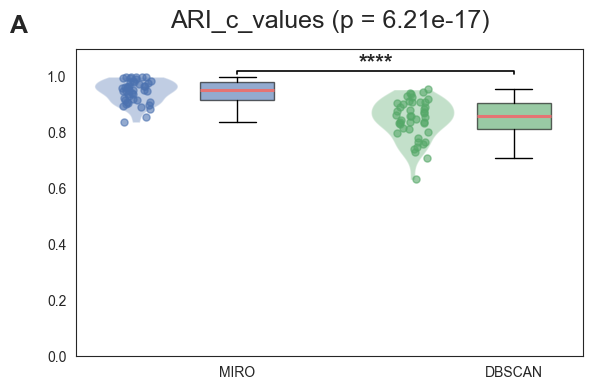


Metric: ARI_dagger_values
n = 45
Mean DBSCAN   = 0.8638
Mean Miro     = 0.8608
Mean diff     = -0.0030  (MIRO - DBSCAN)
t-statistic   = -0.8910
p-value (two-sided (DBSCAN > MIRO)) = 0.377773
Conclusion: no significant difference.


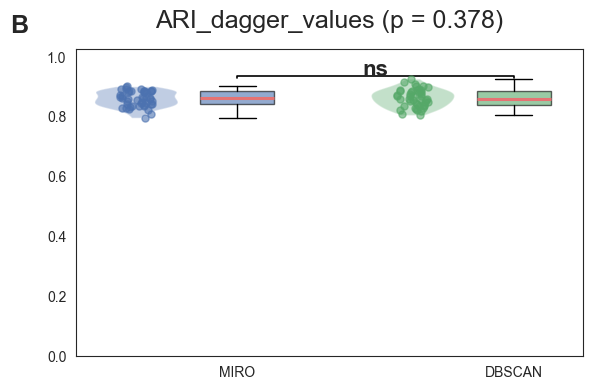


Metric: AMI_values
n = 45
Mean DBSCAN   = 0.8849
Mean Miro     = 0.8864
Mean diff     = 0.0016  (MIRO - DBSCAN)
t-statistic   = 0.5502
p-value (one-sided (MIRO > DBSCAN)) = 0.292496
Conclusion: no significant difference.


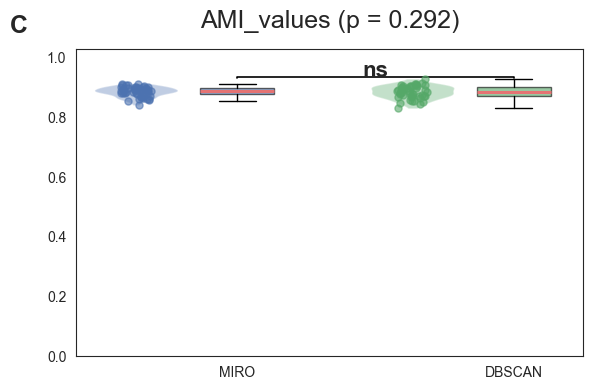


Metric: JIc_values
n = 45
Mean DBSCAN   = 0.9086
Mean Miro     = 0.9712
Mean diff     = 0.0626  (MIRO - DBSCAN)
t-statistic   = 7.3737
p-value (one-sided (MIRO > DBSCAN)) = 1.62526e-09
Conclusion: significant difference.


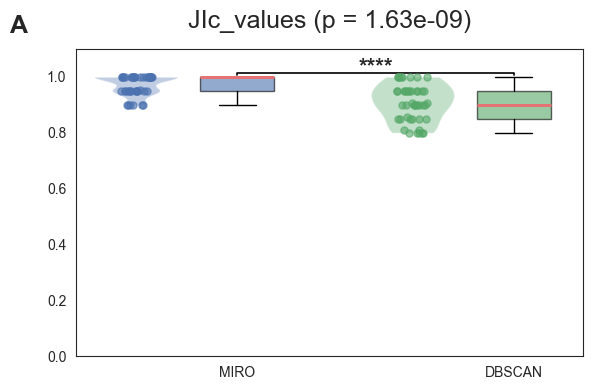


Metric: RMSRE_N_values
n = 45
Mean DBSCAN   = 0.2709
Mean Miro     = 0.1911
Mean diff     = -0.0798  (MIRO - DBSCAN)
t-statistic   = -4.1908
p-value (two-sided (DBSCAN > MIRO)) = 0.000131784
Conclusion: significant difference.


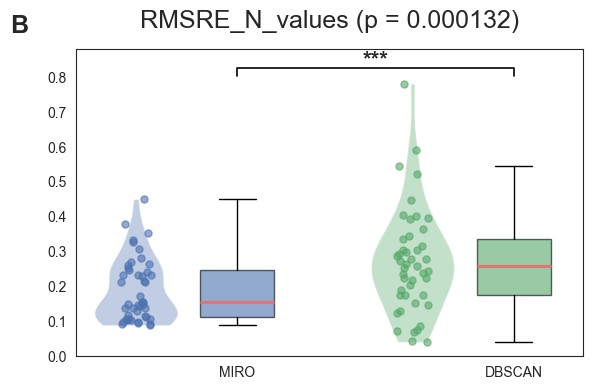


Metric: RMSE_centr_values
n = 45
Mean DBSCAN   = 2.5351
Mean Miro     = 2.2317
Mean diff     = -0.3034  (MIRO - DBSCAN)
t-statistic   = -5.2933
p-value (two-sided (DBSCAN > MIRO)) = 3.63998e-06
Conclusion: significant difference.


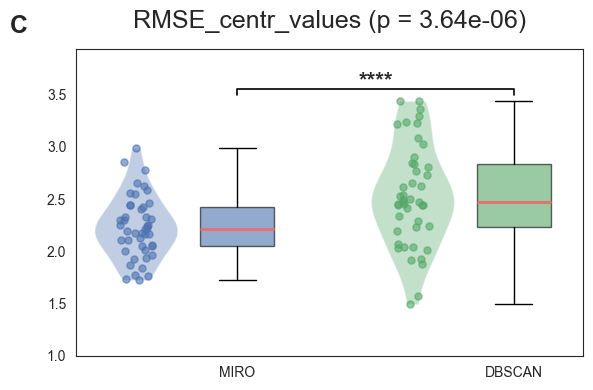

In [184]:
from scipy.stats import ttest_rel

metrics = [ "ARI_c_values", "ARI_dagger_values", "AMI_values", "JIc_values", "RMSRE_N_values", "RMSE_centr_values"]

for metric in metrics:
    paired = pd.DataFrame({
        "dbscan": results_df[metric],
        "miro": results_df2[metric],
    }).dropna()

    db = paired["dbscan"].to_numpy()
    miro = paired["miro"].to_numpy()

    # Paired t-test (two-sided by default)
    t_stat, p_two_sided = ttest_rel(miro, db)

    # === DECISIÓN AUTOMÁTICA ===
    if t_stat > 0:
        # One-sided: H1 = MIRO > DBSCAN
        p_value = p_two_sided / 2
        tail_type = "one-sided (MIRO > DBSCAN)"
    else:
        # Two-sided: DBSCAN > MIRO (dirección contraria)
        p_value = p_two_sided
        tail_type = "two-sided (DBSCAN > MIRO)"

    diff = miro - db

    print(f"\nMetric: {metric}")
    print(f"n = {len(diff)}")
    print(f"Mean DBSCAN   = {db.mean():.4f}")
    print(f"Mean Miro     = {miro.mean():.4f}")
    print(f"Mean diff     = {diff.mean():.4f}  (MIRO - DBSCAN)")
    print(f"t-statistic   = {t_stat:.4f}")
    print(f"p-value ({tail_type}) = {p_value:.6g}")

    if p_value < 0.05:
        print("Conclusion: significant difference.")
    else:
        print("Conclusion: no significant difference.")

    plot_boxplot_sidepoints_scaled(miro, db, metric, p_value)